# WP1.10 - Voltage controlling devices

This notebook demonstrates different combinations of voltage controlling devices in a network with various configurations and controller setups. Error handling (non-convergence of power flow and/or non-convergence of controllers) as well controller oscillation detection and deactivation of controller types is also tested. Tests are based on the definitions in the WP1.10 specification document. 

## Test network configurations

The following schema shows the general 20-bus network used for the tests. Connected loads, sgen and external grids are not shown. 
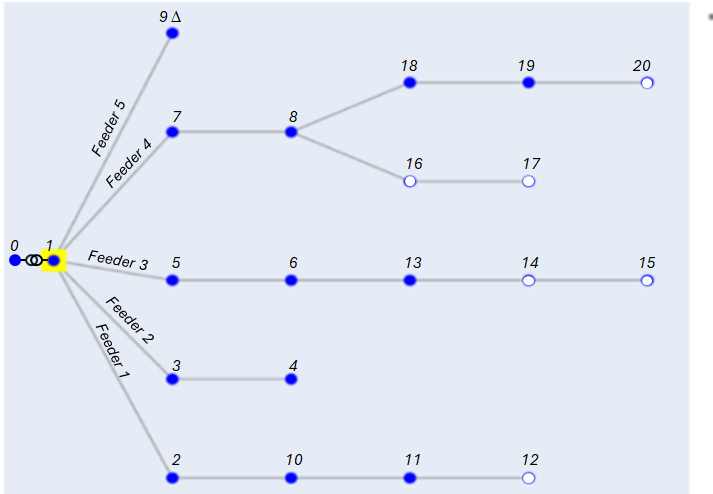

There are three variants of this network. The blue dots represent buses that are the same in all variants. At bus 0, which is the high-voltage side of the transformer, an external network is connected. In the low-voltage part of the network (bus 1..20) in its basic variant, all nodes and lines are 3-phased with neutral conductor, with the exception of bus 9 which has no neutral conductor. In variants 2 and 3, the buses represented by white dots have less than three phases and are connected with according cables with less than four conductors. The following table gives details. 

| Type | Variant 1 (base) | Variant 2 | Variant 3 |
| --- | --- | --- | --- |
| 1-phase with neutral | None | Bus 14,15,16,17 | Bus 16,17,20 | 
| 2-phase with neutral | None | Bus 20 | Bus 12,14,15 | 
| 3-phase without neutral | Bus 9 | Bus 9 | Bus 9 | 
| 3-phase with neutral | All others | All others | All others |

The transformer between buses 0 and 1 is Yy-connected by default, and equipped with a low voltage - side tap controller. 

## Load and Sgen 

Each network configuration can be run in one of two test modes: undervoltage or overvoltage. The test modes are different in the layout of asymmetric loads and sgen connected to the network. In the undervoltage case, there is a total load flow towards the low-voltage side of the transformer; in the overvoltage case, there is a load flow towards the high-voltage side. 

## Controller setups 

There are four different setups for the distribution of controllers in the test network, as shown in the following table. 

| Controller type | Setup 1 | Setup 2 | Setup 3 | Setup 4 |
| --- | --- | --- | --- | --- |
| LDC** (controlled bus) | Bus 13 | Bus 13 | Bus 13 | Bus 13 |
| Volt-Var Controller | Bus 19 | Bus 3,19 | Bus 2,8 | Bus 2,3,6,8 |
| Shunt controller | Bus 11 | Bus 8,11 | Bus 3,19 | Bus 7,10 |

**Instead of the LDC controller, an LTC controller at the transformer low-voltage side may be used.

All volt-var controllers are gang operated and control 3-phased asymmetric sgen at the buses as stated in the table. They are using different QV Curves depending on grid configuration and controller setup. The line drop controller is operated in locked forward mode for the undervoltage test case, and in locked reverse mode for the overvoltage test case. The on-load tap changer controller is configured to phase operation mode and uses a voltage bandwidth of ­±2%. The shunt controllers use voltage tresholds of 0.99 .. 1.02 p.u.  

Also in this work package, we added a gang operation mode to the LDC controller which previously only supported phase operation mode. The new gang operation mode can be activated using an optional flag. The default operation mode for LDC controllers remains phase (cp. Test 15). 

## Test case selection

The setups, configurations and test modes explained above result in a potentially high number of test cases. For demonstration in this notebook, five exemplary test cases were selected for the overvoltage and undervoltage test modes each. Also, for testing failing load flow and failing controller convergence, two special cases are shown. 


## Basic imports

Here, the basic needed functions are imported and the test grids are loaded. 

In [1]:
import multiconductor as mc
import multiconductor.test.testing_toolbox
from multiconductor.pycci.std_types import create_std_type
from multiconductor.control.tools import print_controller_status
from pandapower.control import run_control
import warnings
import pandas as pd 
from math import sqrt
import numpy as np
import copy 

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option('display.float_format', '{:.6f}'.format) 


In [2]:
grids = mc.test.testing_toolbox.load_all_test_grids("wp1_10_voltage_regulating_devices")

NOTE: the following code produces one warning since there is a test case with oscillating controller. This is intentional.

In [3]:
l = []
idx = []
for name, net in grids.items():        
    if 'res_bus_dss' in net.keys():
        net_calc = copy.deepcopy(net)       
        mc.run_pf(net_calc, run_control=True)
        c = multiconductor.test.testing_toolbox.compare_to_dss(net_calc)
        l.append(c)
        idx.append(name)
        print('.', end='')
print()    
pd.DataFrame(l, index=idx).sort_index(key=lambda x: x.str.len())

.............


,max_vm_pu_diff,max_va_degree_diff,max_i_from_ka_diff,max_i_to_ka_diff,max_p_from_mw_diff,max_p_to_mw_diff,max_q_from_mvar_diff,max_q_to_mvar_diff
twenty_bus_system_Yy_LDC_config_1_ctrsetup_3_testmode_overvoltage.pkl,0.000010,0.005891,0.000011,0.000011,0.000000,0.000000,0.000000,0.000001
twenty_bus_system_Yy_LTC_config_2_ctrsetup_2_testmode_overvoltage.pkl,0.000012,0.018348,0.000009,0.000009,0.000000,0.000000,0.000001,0.000000
twenty_bus_system_Yy_LTC_config_3_ctrsetup_4_testmode_overvoltage.pkl,0.000007,0.043571,0.000008,0.000008,0.000000,0.000000,0.000001,0.000001
twenty_bus_system_Yy_LDC_config_3_ctrsetup_2_testmode_overvoltage.pkl,0.000011,0.005608,0.000009,0.000009,0.000000,0.000000,0.000001,0.000001
twenty_bus_system_Yy_LTC_config_1_ctrsetup_1_testmode_overvoltage.pkl,0.000010,0.004266,0.000010,0.000010,0.000000,0.000000,0.000000,0.000000
twenty_bus_system_Yy_LDC_config_1_ctrsetup_2_testmode_undervoltage.pkl,0.000018,0.005176,0.000019,0.000019,0.000000,0.000000,0.000002,0.000002
twenty_bus_system_Yy_LDC_config_1_ctrsetup_4_testmode_undervoltage.pkl,0.000017,0.004667,0.000012,0.000012,0.000000,0.000000,0.000002,0.000001
twenty_bus_system_Yy_LDC_config_3_ctrsetup_3_testmode_undervoltage.pkl,0.000017,0.003584,0.000014,0.000014,0.000000,0.000000,0.000002,0.000002
twenty_bus_system_Yy_LDC_config_1_ctrsetup_3_testmode_undervoltage.pkl,0.000019,0.004707,0.000015,0.000015,0.000000,0.000000,0.000002,0.000002
twenty_bus_system_Yy_LTC_config_2_ctrsetup_2_testmode_undervoltage.pkl,0.000019,0.003175,0.000009,0.000009,0.000000,0.000000,0.000001,0.000001


# Tests for working cases 

For all of the following tests, controllers are expected to converge and narrow the voltage band throughout the network, so that the maximum absolute deviation from the nominal voltage is reduced. 

## Test 1: Network config 1, Controller setup 3 with LDC, overvoltage case

In [4]:
net = grids["twenty_bus_system_Yy_LDC_config_1_ctrsetup_3_testmode_overvoltage.pkl"]             
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 97.83924083548845 (reverse) vm_pu min: 1.0000000003774394 at bus 0, max: 1.063026078656319 at bus 20
Post-Control - Max trafo loading: 96.0268965697093 (reverse) vm_pu min: 0.9788359538538749 at bus 1, max: 1.021448820746123 at bus 20
Controller status: all converged.
Max overall vm_pu difference: 1.0327379038721496e-05
Max overall va_degree difference: 0.00582976439696381
Max overall i_from_ka difference: 1.1309500299816477e-05
Max overall i_to_ka difference: 1.1309500299816477e-05
Max overall p_from_mw difference: 1.1310674815495636e-07
Max overall p_to_mw difference: 1.0471705041287249e-07
Max overall q_from_mvar difference: 4.801811116224124e-07
Max overall q_to_mvar difference: 5.04272517232434e-07

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000   -142.296691    -142.302246
      1      1.000000   1.000000      0.000000       0.

## Test 2: Network config 2, Controller setup 2 with LTC, overvoltage case

In [5]:
net = grids["twenty_bus_system_Yy_LTC_config_2_ctrsetup_2_testmode_overvoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 88.4741088418792 (reverse) vm_pu min: 1.000000000523374 at bus 0, max: 1.059895018295528 at bus 20
Post-Control - Max trafo loading: 87.05641880526875 (reverse) vm_pu min: 0.9840907419632612 at bus 1, max: 1.0140202707625374 at bus 20
Controller status: all converged.
Max overall vm_pu difference: 1.1596779941003277e-05
Max overall va_degree difference: 0.018366858586855273
Max overall i_from_ka difference: 9.442145568638871e-06
Max overall i_to_ka difference: 9.442145568638871e-06
Max overall p_from_mw difference: 4.0185322630614806e-07
Max overall p_to_mw difference: 3.693956960593159e-07
Max overall q_from_mvar difference: 5.359706700559103e-07
Max overall q_to_mvar difference: 4.223693140133211e-07

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000   -148.741729       0.000000
      1      1.000000   1.000000      0.000000       0.0

## Test 3: Network config 1, Controller setup 1 with LTC, overvoltage case

In [6]:
net = grids["twenty_bus_system_Yy_LTC_config_1_ctrsetup_1_testmode_overvoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 97.83924083548845 (reverse) vm_pu min: 1.0000000003774394 at bus 0, max: 1.063026078656319 at bus 20
Post-Control - Max trafo loading: 96.18670587566362 (reverse) vm_pu min: 0.9846858683970224 at bus 1, max: 1.0211637100442907 at bus 15
Controller status: all converged.
Max overall vm_pu difference: 1.0434419435267905e-05
Max overall va_degree difference: 0.004271990374792978
Max overall i_from_ka difference: 1.0352634293386842e-05
Max overall i_to_ka difference: 1.0352634293386842e-05
Max overall p_from_mw difference: 3.1232759467592075e-07
Max overall p_to_mw difference: 2.7566505891862825e-07
Max overall q_from_mvar difference: 4.0036936124927813e-07
Max overall q_to_mvar difference: 2.9013468105798523e-07

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000   -160.653086    -160.657555
      1      1.000000   1.000000      0.000000   

## Test 4: Network config 3, Controller setup 2 with LDC, overvoltage case

In [7]:
net = grids["twenty_bus_system_Yy_LDC_config_3_ctrsetup_2_testmode_overvoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 88.20574671258078 (reverse) vm_pu min: 1.0000000004373213 at bus 0, max: 1.0581679570786235 at bus 20
Post-Control - Max trafo loading: 86.70107169002162 (reverse) vm_pu min: 0.9802701005792613 at bus 1, max: 1.0149585448699918 at bus 15
Controller status: all converged.
Max overall vm_pu difference: 1.1297382285890833e-05
Max overall va_degree difference: 0.00574900983596649
Max overall i_from_ka difference: 9.06964325064763e-06
Max overall i_to_ka difference: 9.06964325064763e-06
Max overall p_from_mw difference: 2.6889113319272795e-07
Max overall p_to_mw difference: 2.47844011369569e-07
Max overall q_from_mvar difference: 5.778659419690413e-07
Max overall q_to_mvar difference: 4.787984972144665e-07

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000    174.197496     174.192746
      1      1.000000   1.000000      0.000000       0.00

## Test 5: Network config 3, Controller setup 4 with LTC, overvoltage case

In [8]:
net = grids["twenty_bus_system_Yy_LTC_config_3_ctrsetup_4_testmode_overvoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 88.20574671258078 (reverse) vm_pu min: 1.0000000004373213 at bus 0, max: 1.0581679570786235 at bus 20
Post-Control - Max trafo loading: 85.31897618151275 (reverse) vm_pu min: 0.9862439313082224 at bus 1, max: 1.0219759119441107 at bus 20
Controller status: all converged.
Max overall vm_pu difference: 7.389657234457836e-06
Max overall va_degree difference: 0.043670346492689305
Max overall i_from_ka difference: 8.124637276007984e-06
Max overall i_to_ka difference: 8.124637276007984e-06
Max overall p_from_mw difference: 3.919503000493485e-07
Max overall p_to_mw difference: 3.870444851838961e-07
Max overall q_from_mvar difference: 7.48613869457071e-07
Max overall q_to_mvar difference: 6.535495608965547e-07

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000   -177.332521       0.000000
      1      1.000000   1.000000      0.000000       0.0

## Test 6: Network config 1, Controller setup 4 with LDC, undervoltage case

In [9]:
net = grids["twenty_bus_system_Yy_LDC_config_1_ctrsetup_4_testmode_undervoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 69.18228115753352 (forward) vm_pu min: 0.9482408731547275 at bus 20, max: 0.9999999993218903 at bus 0
Post-Control - Max trafo loading: 66.89820594215782 (forward) vm_pu min: 0.972421905386527 at bus 15, max: 1.0088497371508742 at bus 1
Controller status: all converged.
Max overall vm_pu difference: 1.6568985204967746e-05
Max overall va_degree difference: 0.004581782277043089
Max overall i_from_ka difference: 1.2381226212360152e-05
Max overall i_to_ka difference: 1.2381226212360152e-05
Max overall p_from_mw difference: 2.978548842014206e-07
Max overall p_to_mw difference: 2.6557063581567064e-07
Max overall q_from_mvar difference: 1.5348485674325507e-06
Max overall q_to_mvar difference: 1.4218536979714036e-06

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000   -108.861922    -108.856298
      1      1.000000   1.000000     -0.000000    

## Test 7: Network config 1, Controller setup 2 with LDC, undervoltage case


In [10]:
net = grids["twenty_bus_system_Yy_LDC_config_1_ctrsetup_2_testmode_undervoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 69.18228115753352 (forward) vm_pu min: 0.9482408731547275 at bus 20, max: 0.9999999993218903 at bus 0
Post-Control - Max trafo loading: 67.66362201341161 (forward) vm_pu min: 0.9744547473508727 at bus 15, max: 1.007413611696816 at bus 1
Controller status: all converged.
Max overall vm_pu difference: 1.831584712830292e-05
Max overall va_degree difference: 0.005208515373235301
Max overall i_from_ka difference: 1.89579139438234e-05
Max overall i_to_ka difference: 1.89579139438234e-05
Max overall p_from_mw difference: 5.817415432707307e-07
Max overall p_to_mw difference: 5.428472709678722e-07
Max overall q_from_mvar difference: 1.8029701122287967e-06
Max overall q_to_mvar difference: 1.6668401592902227e-06

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000   -137.522782    -137.518510
      1      1.000000   1.000000     -0.000000      -0.0

## Test 8: Network config 1, Controller setup 3 with LDC, undervoltage case

In [11]:
net = grids["twenty_bus_system_Yy_LDC_config_1_ctrsetup_3_testmode_undervoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 69.18228115753352 (forward) vm_pu min: 0.9482408731547275 at bus 20, max: 0.9999999993218903 at bus 0
Post-Control - Max trafo loading: 67.68935562624559 (forward) vm_pu min: 0.9767973734036111 at bus 15, max: 1.0072780189415287 at bus 1
Controller status: all converged.
Max overall vm_pu difference: 1.861195208208155e-05
Max overall va_degree difference: 0.0046544561021164554
Max overall i_from_ka difference: 1.5310865860485023e-05
Max overall i_to_ka difference: 1.5310865860485023e-05
Max overall p_from_mw difference: 5.480448515837733e-07
Max overall p_to_mw difference: 5.071283666058246e-07
Max overall q_from_mvar difference: 1.7197445063010797e-06
Max overall q_to_mvar difference: 1.5765368088609122e-06

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000   -121.006982    -121.001693
      1      1.000000   1.000000     -0.000000    

## Test 9: Network config 3, Controller setup 3 with LDC, undervoltage case

In [12]:
net = grids["twenty_bus_system_Yy_LDC_config_3_ctrsetup_3_testmode_undervoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 62.76565276178102 (forward) vm_pu min: 0.9540470747692414 at bus 20, max: 0.9999999994634889 at bus 0
Post-Control - Max trafo loading: 60.71170315773154 (forward) vm_pu min: 0.973341174410619 at bus 15, max: 1.0131706341532807 at bus 19
Controller status: all converged.
Max overall vm_pu difference: 1.6671432129911068e-05
Max overall va_degree difference: 0.0036804457757710907
Max overall i_from_ka difference: 1.4349732859519904e-05
Max overall i_to_ka difference: 1.4349732859519904e-05
Max overall p_from_mw difference: 4.3346738323735146e-07
Max overall p_to_mw difference: 4.121234885856584e-07
Max overall q_from_mvar difference: 1.7803824410855817e-06
Max overall q_to_mvar difference: 1.7056788097630227e-06

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000    -92.417375     -92.412661
      1      1.000000   1.000000     -0.000000  

## Test 10: Network config 2, Controller setup 2 with LTC, undervoltage case

In [13]:
net = grids["twenty_bus_system_Yy_LTC_config_2_ctrsetup_2_testmode_undervoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 56.65882708126959 (forward) vm_pu min: 0.9592226699552914 at bus 15, max: 0.9999999994500856 at bus 0
Post-Control - Max trafo loading: 56.79689132756294 (forward) vm_pu min: 0.9896352418400246 at bus 20, max: 1.012275239103996 at bus 1
Controller status: all converged.
Max overall vm_pu difference: 1.8670077249316464e-05
Max overall va_degree difference: 0.0031771646812401855
Max overall i_from_ka difference: 9.365515682757675e-06
Max overall i_to_ka difference: 9.365515682757675e-06
Max overall p_from_mw difference: 4.530634025029512e-07
Max overall p_to_mw difference: 4.4362610963910587e-07
Max overall q_from_mvar difference: 1.1030951567979341e-06
Max overall q_to_mvar difference: 1.0700646317224338e-06

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000   -150.888697    -150.885976
      1      1.000000   1.000000     -0.000000     

## Test 11: Network config 3, Controller setup 3 with gang-operated LTC and Dy trafo, overvoltage case

In [14]:
net = grids["twenty_bus_system_Dy_LTCgang_config_3_ctrsetup_3_testmode_overvoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 88.20574660110367 (reverse) vm_pu min: 1.0000000004340166 at bus 0, max: 1.0581679591590323 at bus 20
Post-Control - Max trafo loading: 86.15015066557929 (reverse) vm_pu min: 0.9837044914029907 at bus 1, max: 1.0184430243320355 at bus 15
Controller status: all converged.
Max overall vm_pu difference: 1.009597669665574e-05
Max overall va_degree difference: 0.05150307572544932
Max overall i_from_ka difference: 9.130025965586874e-06
Max overall i_to_ka difference: 9.130025965586874e-06
Max overall p_from_mw difference: 5.033349137206766e-07
Max overall p_to_mw difference: 4.915149472151104e-07
Max overall q_from_mvar difference: 8.505031816724469e-07
Max overall q_to_mvar difference: 9.295959204052434e-07

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000      0.000000       0.000000
      1      1.000000   1.000000      0.000000       0.0

## Test 12: Network config 2, Controller setup 4 with gang-operated LTC and Dy trafo, overvoltage case

In [15]:
net = grids["twenty_bus_system_Dy_LTCgang_config_2_ctrsetup_4_testmode_overvoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 88.47410880043299 (reverse) vm_pu min: 1.0000000005309504 at bus 0, max: 1.0598950164389043 at bus 20
Post-Control - Max trafo loading: 85.55315329293674 (reverse) vm_pu min: 0.986629776630723 at bus 1, max: 1.0143765107223992 at bus 20
Controller status: all converged.
Max overall vm_pu difference: 8.486449880829028e-06
Max overall va_degree difference: 0.03355573815751711
Max overall i_from_ka difference: 7.08543119731786e-06
Max overall i_to_ka difference: 7.08543119731786e-06
Max overall p_from_mw difference: 1.5639091212327205e-07
Max overall p_to_mw difference: 1.6236804378788605e-07
Max overall q_from_mvar difference: 5.117109312304663e-07
Max overall q_to_mvar difference: 4.5315776133156315e-07

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000      0.000000       0.000000
      1      1.000000   1.000000      0.000000       0.0

## Test 13: Network config 2, Controller setup 3 with gang-operated LTC and Dy trafo, undervoltage case 	

In [16]:
net = grids["twenty_bus_system_Dy_LTCgang_config_2_ctrsetup_3_testmode_undervoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 56.661046855197796 (forward) vm_pu min: 0.9592226742974387 at bus 15, max: 0.9999999993283375 at bus 0
Post-Control - Max trafo loading: 57.401188807158164 (forward) vm_pu min: 0.9892826260389443 at bus 15, max: 1.0186581519066338 at bus 3
Controller status: all converged.
Max overall vm_pu difference: 1.99041646999909e-05
Max overall va_degree difference: 0.030293083438323265
Max overall i_from_ka difference: 9.888308661998302e-06
Max overall i_to_ka difference: 9.888308661998302e-06
Max overall p_from_mw difference: 2.9115085302400256e-07
Max overall p_to_mw difference: 2.766798562064965e-07
Max overall q_from_mvar difference: 1.1566931266485114e-06
Max overall q_to_mvar difference: 1.1489384671645175e-06

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000      0.000000       0.000000
      1      1.000000   1.000000     -0.000000     

## Test 14: Network config 3, Controller setup 4 with gang-operated LTC and Dy trafo, undervoltage case 	

In [17]:
net = grids["twenty_bus_system_Dy_LTCgang_config_3_ctrsetup_4_testmode_undervoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 62.76788775714027 (forward) vm_pu min: 0.9540470806349187 at bus 20, max: 0.9999999994179203 at bus 0
Post-Control - Max trafo loading: 63.60281164918258 (forward) vm_pu min: 0.9845499767933714 at bus 20, max: 1.0215421126908213 at bus 1
Controller status: all converged.
Max overall vm_pu difference: 2.2591286062745297e-05
Max overall va_degree difference: 0.034073590162051914
Max overall i_from_ka difference: 1.4432249395901486e-05
Max overall i_to_ka difference: 1.4432249395901486e-05
Max overall p_from_mw difference: 2.937105107859284e-07
Max overall p_to_mw difference: 2.925111330052141e-07
Max overall q_from_mvar difference: 1.5052745848745386e-06
Max overall q_to_mvar difference: 1.401465957555359e-06

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000      0.000000       0.000000
      1      1.000000   1.000000     -0.000000     

## Test 15: Network config 2, Controller setup 3 with gang-operated LDC, undervoltage case
This case demonstrates the newly added gang operation mode for LDC. 

In [18]:
net = grids["twenty_bus_system_Dy_LDCgang_config_2_ctrsetup_3_testmode_undervoltage.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 56.661046855197796 (forward) vm_pu min: 0.9592226742974387 at bus 15, max: 0.9999999993283375 at bus 0
Post-Control - Max trafo loading: 56.56537974815776 (forward) vm_pu min: 0.9844835747466155 at bus 15, max: 1.0139134399345402 at bus 3
Controller status: all converged.
Max overall vm_pu difference: 1.821394387535591e-05
Max overall va_degree difference: 0.030325267346569262
Max overall i_from_ka difference: 9.353585011001586e-06
Max overall i_to_ka difference: 9.353585011001586e-06
Max overall p_from_mw difference: 2.7534127645945095e-07
Max overall p_to_mw difference: 2.6256312070371823e-07
Max overall q_from_mvar difference: 1.0848431451770946e-06
Max overall q_to_mvar difference: 1.0779951419882805e-06

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0      0.000000   0.000000      0.000000       0.000000
      1      1.000000   1.000000     -0.000000    

# Tests for failure cases


# Load flow failure 

The following code demonstrates the result of executing a load flow on a network that is not configured properly. More specifically, bus 6 of the 20-bus network above is taken out of service, creating two network parts one of which is unsupplied. There are multiple other reasons for load flow failure but the error message as seen here is typical. Through using a try..except block and print_controller_status(), the failure may be differentiated from a controller non-convergence case. 

In [19]:
net = grids["twenty_bus_system_Yy_LDC_config_2_ctrsetup_1_testmode_undervoltage_lf_fail.pkl"]
net_pre_control = copy.deepcopy(net) 
try:
    mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
    print("Pre-Control - ",end='')
    multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
    mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
    print("Post-Control - ",end='')
    multiconductor.test.testing_toolbox.print_minmax(net)
    print_controller_status(net)  
except Exception as X:
    print("Load flow or controller failure.")
    print("Exception: "+str(X))
    print_controller_status(net)  

Load flow or controller failure.
Exception: Factor is exactly singular
Controller status: no load flow results available.


# Controller non-convergence

The following code demonstrates the result of executing a load flow on a network with controllers that fail to converge. This was obtained by using the network above in config 2, controller setup 4 with LDC in the undervoltage situation, and using a different QV Curve for one of the volt_var controllers. While the python exception only specifies that some controller(s) did not converge, the output of print_controller_status() clearly specifies the failing controller and controlled element.

In [20]:
net = copy.deepcopy(grids["twenty_bus_system_Yy_LDC_config_3_ctrsetup_4_testmode_undervoltage_ctr_fail.pkl"])
net_pre_control = copy.deepcopy(net) 

try:
    mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
    print("Pre-Control - ",end='')
    multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
    mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
    print("Post-Control - ",end='')
    multiconductor.test.testing_toolbox.print_minmax(net)
    print_controller_status(net)  
except Exception as X:
    print("Load flow or controller failure.")
    print("Exception: "+str(X))
    print_controller_status(net)  

Pre-Control - Max trafo loading: 62.76565276178102 (forward) vm_pu min: 0.9540470747692414 at bus 20, max: 0.9999999994634889 at bus 0
Load flow or controller failure.
Exception: Maximum number of iterations per controller is reached. Some controller did not converge after 61 calculations!
Controller status:
VoltVarControl for asymmetric_sgen index [(4, 0), (4, 1), (4, 2)] (controller index 5) did not converge.


The following code re-tries the same setup, but uses one of the newly introduced flags for run_pf to deactivate all volt-var controllers. This time the network converges and print_controller_status() lists all deactivated controllers. Note that after using one of the flags to deactivate a controller type, this type will remain deactivated for all following run_pf() calls. In order to reactivate the controller type, the flag must be used again and set True. 

In [21]:
net = copy.deepcopy(grids["twenty_bus_system_Yy_LDC_config_3_ctrsetup_4_testmode_undervoltage_ctr_fail.pkl"])
net_pre_control = copy.deepcopy(net) 

try:
    mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
    print("Pre-Control - ",end='')
    multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
    mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True, run_voltvar_control=False)                        
    print("Post-Control - ",end='')
    multiconductor.test.testing_toolbox.print_minmax(net)
    print_controller_status(net)  
except Exception as X:
    print("Load flow or controller failure.")
    print("Exception: "+str(X))
    print_controller_status(net)  

Pre-Control - Max trafo loading: 62.76565276178102 (forward) vm_pu min: 0.9540470747692414 at bus 20, max: 0.9999999994634889 at bus 0
Post-Control - Max trafo loading: 61.32075033622587 (forward) vm_pu min: 0.976167476512151 at bus 15, max: 1.0104871172371863 at bus 19
Controller status:
VoltVarControl for asymmetric_sgen index [(0, 0), (0, 1), (0, 2)] (controller index 1) is out of service.
VoltVarControl for asymmetric_sgen index [(1, 0), (1, 1), (1, 2)] (controller index 2) is out of service.
VoltVarControl for asymmetric_sgen index [(2, 0), (2, 1), (2, 2)] (controller index 3) is out of service.
VoltVarControl for asymmetric_sgen index [(3, 0), (3, 1), (3, 2)] (controller index 4) is out of service.
VoltVarControl for asymmetric_sgen index [(4, 0), (4, 1), (4, 2)] (controller index 5) is out of service.
Controller status: all converged.


# Controller oscillation

The following code demonstrates the behaviour with an oscillating gang-operated LTC controller, which was created with detect_oscillation=True. The case uses grid configuration 2, controller setup 4 in the undervoltage testmode. The oscillation occurs because the voltage bandwidth for the LTC was selected too narrow. In this case, the controller converges as soon as oscillation is detected, even if some of the controlled voltages at the secondary-side trafo terminal are out of spec. 
As can be seen, a warning is produced during the load flow calculation. Also, the output of print_controller_status() specifies that the controller did converge, but is oscillating.  	

In [22]:
net = grids["twenty_bus_system_Dy_LTCgang_config_2_ctrsetup_4_testmode_undervoltage_ctrosc.pkl"]
net_pre_control = copy.deepcopy(net) 

mc.run_pf(net_pre_control, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=False)
print("Pre-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net_pre_control)
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, run_control=True)                        
print("Post-Control - ",end='')
multiconductor.test.testing_toolbox.print_minmax(net)
print_controller_status(net)  
print()

c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print("\nbus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print("\nline results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Pre-Control - Max trafo loading: 56.661046855197796 (forward) vm_pu min: 0.9592226742974387 at bus 15, max: 0.9999999993283375 at bus 0
Post-Control - Max trafo loading: 59.437766027611225 (forward) vm_pu min: 0.9934547885640691 at bus 20, max: 1.0242581017603416 at bus 1
Controller status: all converged.
LineDropControlExtended for trafo1ph top level index 0 (controller index 0) converged but oscillates.

Max overall vm_pu difference: 2.351650189724719e-05
Max overall va_degree difference: 0.02801870247881766
Max overall i_from_ka difference: 1.0830088015445494e-05
Max overall i_to_ka difference: 1.0830088015445494e-05
Max overall p_from_mw difference: 3.542280453405766e-07
Max overall p_to_mw difference: 3.343166775082729e-07
Max overall q_from_mvar difference: 4.948233616811071e-07
Max overall q_to_mvar difference: 4.314545791507529e-07

bus results
             vm_pu_mc  vm_pu_dss  va_degree_mc  va_degree_dss
index phase                                                  
0     0    